In [1]:
import os
os.chdir("../dgl_ptm/")

import sys
import zarr
import time
import pickle
import dgl_ptm
import numpy as np
import networkx as nx

from tqdm.auto import tqdm
from dgl_ptm.util.utils import sample_distribution_tensor

os.environ["DGLBACKEND"] = "pytorch"
import torch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from collections import Counter
import matplotlib
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": True, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

In [2]:
def create_model(seed=42, identifier="sveir_test", num_agents=10000, steps=100, new_node_edges=5):
    model = dgl_ptm.SVEIRModel(model_identifier=identifier)
    model.set_model_parameters(**{
        'number_agents': num_agents,
        'seed': seed,
        'spatial': True,
        'spatial_creation_args':{
            "method": "custom_import",
            "path": "ghana_grid.npy",
            "properties": {"population": 0}
        },
        'spatial_assignment_args':{'method':"property",'property':"population"},
        'initial_graph_type': 'barabasi-albert',
        'initial_graph_args': {'seed': seed, 'new_node_edges':new_node_edges},
        'device': 'cpu',
        'step_target': steps,
        'steering_parameters': {
            'npath':'./agent_data.zarr',
            'epath':'./edge_data',
            'ndata':[['compartments', 'num_infections'],['initial_only',[]]],
            'edata': None,
            'mode': 'w',
            'proximity_decay_rate': 0.05,
            'truncation_weight': 1e-10,
            'infection_probability': 0.3,
            'recovery_rate': 0.1,
            'vaccination_rate': 0.01,
            'vaccine_efficacy': 0.9,
            'exposure_period': 5,
            'initial_infected_proportion': 0.05,
            'step_type': 'seir'
        }
    })
    model.initialize_model()
    return model

In [3]:
# m = create_model(num_agents=15, seed=1)
# g = m.graph

# timea = time.time()

# num_nodes = g.num_nodes()
# src, dst = g.edges()
# edge_weights = torch.zeros((num_nodes, num_nodes))
# edge_weights[src, dst] = g.edata["weight"]

# # num nodes x num nodes matrix containing edges weights for infected nodes, otherwise 0
# susceptible_nodes = (g.ndata["compartments"] == 0).nonzero(as_tuple=True)[0]
# infected_weights = torch.where(g.ndata["compartments"].repeat(num_nodes, 1) == 3, edge_weights, 0)[susceptible_nodes]

# nonzero_weights = torch.where(infected_weights > 0)

# RNG = torch.rand((2, nonzero_weights[0].shape[0]))

# RNG1 = torch.zeros_like(infected_weights)
# RNG1[nonzero_weights] = RNG[0]
# RNG2 = torch.zeros_like(infected_weights)
# RNG2[nonzero_weights] = RNG[1]

# infection = (infected_weights > 0).type(torch.float32) * (RNG1 < infected_weights) * (RNG2 < m.steering_parameters["infection_probability"])
# infected_nodes = susceptible_nodes[torch.where(infection.sum(axis=1) > 0)]

# g.ndata["compartments"][infected_nodes] = 0
# g.ndata["exposure_time"][infected_nodes] = 0

# print(time.time()-timea)

### Profiling

In [3]:
agent_array = [1024, 4096, 16384, 131072, 1048576]
nne_array = [2, 4, 8]

T = {}
avg_deg = []

for nne in nne_array:
    T[nne] = {}
    for n_agents in tqdm(agent_array):
        model = create_model(num_agents=n_agents, new_node_edges=nne)
        if n_agents == agent_array[-1]:
            G = model.graph.to_networkx()
            avg_deg.append(round(sum(dict(G.degree()).values()) / n_agents))
        time_start = time.time()
        model.run()
        T[nne][n_agents] = time.time() - time_start

# with open("../DGL_testing/profiling_results.pickle", "wb") as f:
#     pickle.dump({
#         "avg_deg": avg_deg,
#         "time": T
#     }, f)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
with open("../DGL_testing/profiling_results.pickle", "rb") as f:
    profiling_result = pickle.load(f)

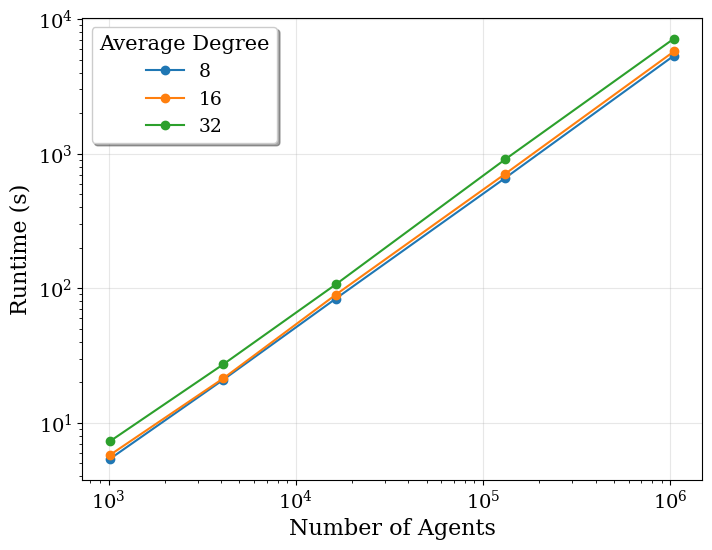

In [30]:
for i,nne in enumerate(profiling_result["time"]):
    plt.plot(
        list(profiling_result["time"][2].keys()),
        list(profiling_result["time"][nne].values()),
        label=profiling_result["avg_deg"][i],
        marker='o'
    )
plt.legend(shadow=True, title="Average Degree")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of Agents")
plt.ylabel("Runtime (s)")
# plt.savefig("profiling.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# dist = []
# u, v = model.graph.edges()
# x_u = model.graph.ndata['x'][u]
# y_u = model.graph.ndata['y'][u]
# x_v = model.graph.ndata['x'][v]
# y_v = model.graph.ndata['y'][v]
# distance = torch.sqrt((x_u - x_v)**2 + (y_u - y_v)**2)
# plt.scatter(distance, model.graph.edata["weight"])
# plt.show()

# nx.draw(model.graph.to_networkx())

# plt.imshow(model.grid_environment.get_slice("population"), norm=LogNorm())
# plt.gca().invert_yaxixs()
# plt.scatter(model.graph.ndata['x'], model.graph.ndata['y'], c="red", s=10, alpha=0.3)
# plt.show()

### Results

In [4]:
model = create_model(num_agents=1000, new_node_edges=2)
model.run()

In [5]:
mapping = {
    "S":0,
    "V":1,
    "E":2,
    "I":3,
    "R":4
}
rev_mapping = {v:k for k,v in mapping.items()}

In [6]:
compartment_data = zarr.load('./sveir_test/agent_data.zarr/compartments')

In [7]:
SVEIR = {c:[] for c in mapping}
for col in range(compartment_data.shape[1]):
    time_step = compartment_data[:,col]
    counts = dict(Counter(time_step))
    for compartment, count in counts.items():
        SVEIR[rev_mapping[compartment]].append(count)

for k in SVEIR:
    while len(SVEIR[k]) < compartment_data.shape[1]:
        SVEIR[k].append(0)

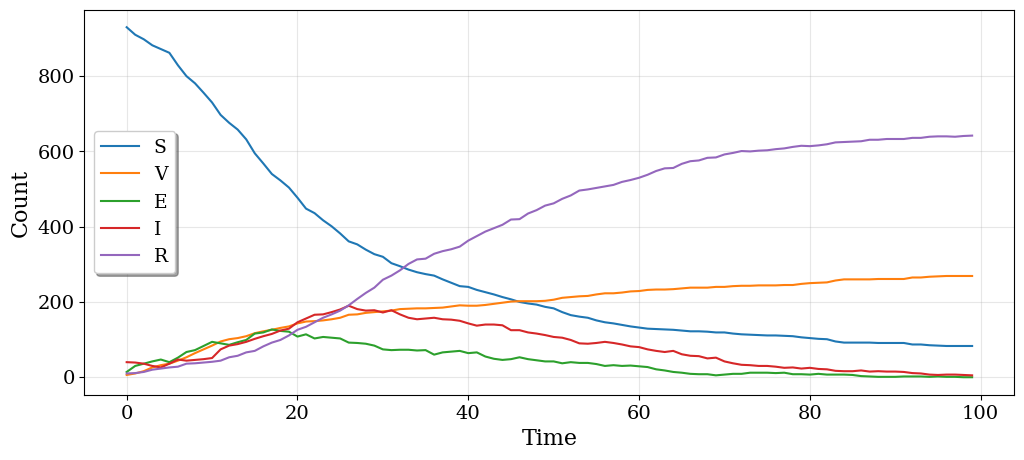

In [8]:
plt.figure(figsize=(12,5))

for c in SVEIR:
    plt.plot(SVEIR[c], label=c)

plt.legend(shadow=True)
plt.xlabel("Time")
plt.ylabel("Count")
plt.savefig("SVEIR_curves.pdf", bbox_inches="tight")
plt.show()